## Imports

In [1]:
import os
import random
from pathlib import Path
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import clip_grad_norm_
from torch.optim.lr_scheduler import CosineAnnealingLR

from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

## visualisation code

In [2]:
# Enable inline plotting for Jupyter
%matplotlib inline

# Set publication-quality style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100  # Lower for notebook display, saved figures will be 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

class TrainingLogger:
    """Logger to track training metrics epoch-by-epoch"""
    def __init__(self):
        self.history = {
            'epoch': [],
            'train_loss': [],
            'val_loss': [],
            'train_acc_species': [],
            'val_acc_species': [],
            'train_acc_health': [],
            'val_acc_health': [],
            'train_acc_both': [],
            'val_acc_both': [],
            'lr': []
        }
    
    def log_epoch(self, epoch, train_stats, val_stats, lr):
        """Log metrics for one epoch"""
        self.history['epoch'].append(epoch)
        self.history['train_loss'].append(train_stats['loss'])
        self.history['val_loss'].append(val_stats['loss'])
        self.history['train_acc_species'].append(train_stats['acc_species'])
        self.history['val_acc_species'].append(val_stats['acc_species'])
        self.history['train_acc_health'].append(train_stats['acc_health'])
        self.history['val_acc_health'].append(val_stats['acc_health'])
        self.history['train_acc_both'].append(train_stats['acc_both'])
        self.history['val_acc_both'].append(val_stats['acc_both'])
        self.history['train_f1_joint'].append(train_stats['f1_joint'])
        self.history['val_f1_joint'].append(val_stats['f1_joint'])
        self.history['lr'].append(lr)
    
    def plot_convergence(self, save_path='training_convergence.png', model_name='Model', show=True):
        """
        Create publication-quality convergence plots
        
        Args:
            save_path: Path to save the figure
            model_name: Name of the model for the title
            show: Whether to display the plot in notebook (default: True)
        """
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f'{model_name} Training Convergence', fontsize=14, fontweight='bold', y=0.995)
        
        epochs = self.history['epoch']
        
        # Plot 1: Training and Validation Loss
        ax1 = axes[0, 0]
        ax1.plot(epochs, self.history['train_loss'], 'o-', label='Train Loss', 
                linewidth=2, markersize=4, color='#2E86AB', alpha=0.8)
        ax1.plot(epochs, self.history['val_loss'], 's-', label='Val Loss', 
                linewidth=2, markersize=4, color='#A23B72', alpha=0.8)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('(a) Multi-task Loss', fontweight='bold', loc='left')
        ax1.legend(framealpha=0.9)
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Species Accuracy
        ax2 = axes[0, 1]
        ax2.plot(epochs, self.history['train_acc_species'], 'o-', label='Train Species', 
                linewidth=2, markersize=4, color='#2E86AB', alpha=0.8)
        ax2.plot(epochs, self.history['val_acc_species'], 's-', label='Val Species', 
                linewidth=2, markersize=4, color='#A23B72', alpha=0.8)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.set_title('(b) Species Classification', fontweight='bold', loc='left')
        ax2.set_ylim([0, 1.05])
        ax2.legend(framealpha=0.9)
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Disease Accuracy
        ax3 = axes[1, 0]
        ax3.plot(epochs, self.history['train_acc_health'], 'o-', label='Train Disease', 
                linewidth=2, markersize=4, color='#2E86AB', alpha=0.8)
        ax3.plot(epochs, self.history['val_acc_health'], 's-', label='Val Disease', 
                linewidth=2, markersize=4, color='#A23B72', alpha=0.8)
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Accuracy')
        ax3.set_title('(c) Disease Detection', fontweight='bold', loc='left')
        ax3.set_ylim([0, 1.05])
        ax3.legend(framealpha=0.9)
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Joint Accuracy (Both Correct)
        ax4 = axes[1, 1]
        ax4.plot(epochs, self.history['train_acc_both'], 'o-', label='Train Both', 
                linewidth=2, markersize=4, color='#2E86AB', alpha=0.8)
        ax4.plot(epochs, self.history['val_acc_both'], 's-', label='Val Both', 
                linewidth=2, markersize=4, color='#A23B72', alpha=0.8)
        
        # Mark best validation epoch
        best_epoch_idx = np.argmax(self.history['val_acc_both'])
        best_epoch = epochs[best_epoch_idx]
        best_val_both = self.history['val_acc_both'][best_epoch_idx]
        ax4.axvline(x=best_epoch, color='red', linestyle='--', 
                   linewidth=1.5, alpha=0.6, label=f'Best (Epoch {best_epoch})')
        ax4.plot(best_epoch, best_val_both, 'r*', markersize=15, 
                markeredgecolor='darkred', markeredgewidth=1.5)
        
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('Accuracy')
        ax4.set_title('(d) Joint Accuracy (Primary Metric)', fontweight='bold', loc='left')
        ax4.set_ylim([0, 1.05])
        ax4.legend(framealpha=0.9)
        ax4.grid(True, alpha=0.3)
        
        # Add annotation for best performance
        ax4.annotate(f'{best_val_both:.3f}', 
                    xy=(best_epoch, best_val_both),
                    xytext=(10, -15), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='red'),
                    fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✓ Convergence plot saved to: {save_path}")
        
        if show:
            plt.show()
        else:
            plt.close()
    
    def plot_learning_rate(self, save_path='learning_rate_schedule.png', show=True):
        """Plot learning rate schedule"""
        fig, ax = plt.subplots(figsize=(10, 4))
        
        epochs = self.history['epoch']
        ax.plot(epochs, self.history['lr'], 'o-', linewidth=2, 
               markersize=5, color='#F18F01', label='Learning Rate')
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Learning Rate')
        ax.set_title('Learning Rate Schedule (Cosine Annealing)', fontweight='bold')
        ax.legend(framealpha=0.9)
        ax.grid(True, alpha=0.3)
        ax.set_yscale('log')
        
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✓ Learning rate plot saved to: {save_path}")
        
        if show:
            plt.show()
        else:
            plt.close()
    
    def plot_comparison(self, other_loggers, labels, save_path='model_comparison.png', show=True):
        """
        Compare multiple models on the same plot
        
        Args:
            other_loggers: List of other TrainingLogger instances
            labels: List of model names
            save_path: Path to save comparison figure
            show: Whether to display the plot in notebook
        """
        all_loggers = [self] + other_loggers
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        fig.suptitle('Multi-Model Performance Comparison', fontsize=14, fontweight='bold')
        
        colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4B51', '#8B5A3C']
        
        # Plot 1: Validation Loss Comparison
        ax1 = axes[0]
        for i, (logger, label) in enumerate(zip(all_loggers, labels)):
            ax1.plot(logger.history['epoch'], logger.history['val_loss'], 
                    'o-', label=label, linewidth=2, markersize=4, 
                    color=colors[i % len(colors)], alpha=0.8)
        
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Validation Loss')
        ax1.set_title('(a) Validation Loss', fontweight='bold', loc='left')
        ax1.legend(framealpha=0.9, loc='best')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Joint Accuracy Comparison
        ax2 = axes[1]
        for i, (logger, label) in enumerate(zip(all_loggers, labels)):
            ax2.plot(logger.history['epoch'], logger.history['val_acc_both'], 
                    'o-', label=label, linewidth=2, markersize=4, 
                    color=colors[i % len(colors)], alpha=0.8)
        
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Validation Joint Accuracy')
        ax2.set_title('(b) Joint Accuracy (Both Correct)', fontweight='bold', loc='left')
        ax2.set_ylim([0, 1.05])
        ax2.legend(framealpha=0.9, loc='best')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✓ Comparison plot saved to: {save_path}")
        
        if show:
            plt.show()
        else:
            plt.close()
    
    def save_history(self, save_path='training_history.csv'):
        """Save training history to CSV"""
        df = pd.DataFrame(self.history)
        df.to_csv(save_path, index=False)
        print(f"✓ Training history saved to: {save_path}")

print("✓ TrainingLogger class loaded successfully!")
def plot_joint_confusion_matrix(y_true, y_pred, save_path='joint_confusion_matrix.png'):
    labels = [
        "Guava-Healthy", "Guava-Anthracnose",
        "Mango-Healthy", "Mango-Anthracnose",
        "Papaya-Healthy", "Papaya-Anthracnose"
    ]
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Joint Confusion Matrix (Species + Health)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"✓ Confusion matrix saved to {save_path}")


✓ TrainingLogger class loaded successfully!


## training code

In [3]:
# -------------------------------
# Config
# -------------------------------
DATA_ROOT = Path("/workspace/Dataset_split")  
IMG_SIZE  = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 5e-4
DROPOUT = 0.3
NUM_SPECIES = 3
NUM_HEALTH = 2
PRETRAINED = False
GRADIENT_CLIP = 1.0
PATIENCE = 5
SEED = 42
LOSS_WEIGHT_HEALTH = 1.0
USE_AMP = True
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
                      else "cpu")
print("Device:", device)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -------------------------------
# Label maps
# -------------------------------
SPECIES_MAP = {"Guava":0, "Mango":1, "Papaya":2}
HEALTH_MAP  = {"Healthy":0, "Anthracnose":1}

def parse_joint_label(folder_name: str) -> Tuple[int,int]:
    name = folder_name.strip()
    if "_" not in name:
        raise ValueError(f"Folder name not joint label: {name}")
    sp, he = name.split("_", 1)
    sp_id = SPECIES_MAP[sp]
    he_id = HEALTH_MAP[he]
    return sp_id, he_id

# -------------------------------
# Dataset
# -------------------------------
class JointLeafDataset(Dataset):
    def __init__(self, split_root: Path, transform=None):
        self.split_root = Path(split_root)
        self.samples: List[Tuple[str, int, int]] = []
        self.transform = transform
        for folder in sorted([d for d in self.split_root.iterdir() if d.is_dir()]):
            sp_id, he_id = parse_joint_label(folder.name)
            for p in folder.rglob("*"):
                if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
                    self.samples.append((str(p), sp_id, he_id))
        if len(self.samples) == 0:
            raise RuntimeError(f"No images found under {split_root}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, sp_id, he_id = self.samples[idx]
       
        try:
            img = Image.open(path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {path}: {e}")
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
       
        if self.transform is not None:
            img = self.transform(img)
       
        return img, torch.tensor(sp_id, dtype=torch.long), torch.tensor(he_id, dtype=torch.long)

# -------------------------------
# Transforms (offline augmentation already applied)
# -------------------------------
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# -------------------------------
# Datasets & Loaders
# -------------------------------
print("Loading datasets...")
train_ds = JointLeafDataset(DATA_ROOT / "train", transform=train_tf)
val_ds   = JointLeafDataset(DATA_ROOT / "val",   transform=eval_tf)
test_ds  = JointLeafDataset(DATA_ROOT / "test",  transform=eval_tf)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# Test loading one sample
print("\nTesting sample loading...")
try:
    sample_img, sample_sp, sample_he = train_ds[0]
    print(f"✓ Sample loaded successfully: shape={sample_img.shape}, species={sample_sp}, health={sample_he}")
except Exception as e:
    print(f"✗ Failed to load sample: {e}")
    raise

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))

# Test DataLoader
print("\nTesting DataLoader...")
try:
    for i, (imgs, sp, he) in enumerate(train_loader):
        print(f"✓ Batch {i}: imgs {imgs.shape}, species {sp.shape}, health {he.shape}")
        if i >= 2:
            break
    print("✓ DataLoader test passed!\n")
except Exception as e:
    print(f"✗ DataLoader failed: {e}")
    import traceback
    traceback.print_exc()

    raise

Device: cuda
Loading datasets...
Train: 6000 | Val: 749 | Test: 768

Testing sample loading...
✓ Sample loaded successfully: shape=torch.Size([3, 224, 224]), species=0, health=1

Testing DataLoader...
✓ Batch 0: imgs torch.Size([32, 3, 224, 224]), species torch.Size([32]), health torch.Size([32])
✓ Batch 1: imgs torch.Size([32, 3, 224, 224]), species torch.Size([32]), health torch.Size([32])
✓ Batch 2: imgs torch.Size([32, 3, 224, 224]), species torch.Size([32]), health torch.Size([32])
✓ DataLoader test passed!



## Model Definition

In [4]:
# -------------------------------
# Model
# -------------------------------
class MultiTaskResNet50(nn.Module):
    def __init__(self, num_species=NUM_SPECIES, num_health=NUM_HEALTH, pretrained=PRETRAINED, dropout=DROPOUT):
        super().__init__()
        if pretrained:
            weights = ResNet50_Weights.IMAGENET1K_V1
            self.backbone = resnet50(weights=weights)
        else:
            self.backbone = resnet50(weights=None)
        
        in_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        
        self.dropout = nn.Dropout(dropout)
        self.head_species = nn.Linear(in_dim, num_species)
        self.head_health = nn.Linear(in_dim, num_health)
    
    def forward(self, x):
        feats = self.backbone(x)
        feats = self.dropout(feats)
        logits_species = self.head_species(feats)
        logits_health = self.head_health(feats)
        return logits_species, logits_health

print("Initializing model...")
model = MultiTaskResNet50(num_species=NUM_SPECIES, num_health=NUM_HEALTH, pretrained=PRETRAINED, dropout=DROPOUT).to(device)
print("Model loaded\n")


# -------------------------------
# Optimizer / Scheduler / Losses
# -------------------------------
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion_species = nn.CrossEntropyLoss()
criterion_health  = nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and device.type=="cuda")

# -------------------------------
# Utilities
# -------------------------------
def accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

def run_epoch(loader, model, optimizer=None, train=True, epoch=0):
    if train:
        model.train()
    else:
        model.eval()
    
    running = {
        "loss": 0.0,
        "acc_species": 0.0,
        "acc_health":  0.0,
        "acc_both":    0.0,
        "f1_joint":    0.0,
        "n": 0
    }
    
    # Storage for all predictions and targets to calculate F1
    all_preds_sp = []
    all_preds_he = []
    all_targets_sp = []
    all_targets_he = []
    
    total_batches = len(loader)
   
    for batch_idx, (imgs, y_species, y_health) in enumerate(loader):
        imgs = imgs.to(device, non_blocking=True)
        y_species = y_species.to(device, non_blocking=True)
        y_health  = y_health.to(device, non_blocking=True)
        
        with torch.set_grad_enabled(train):
            if USE_AMP and device.type=="cuda":
                with torch.cuda.amp.autocast():
                    logits_species, logits_health = model(imgs)
                    loss = criterion_species(logits_species, y_species) + \
                           LOSS_WEIGHT_HEALTH * criterion_health(logits_health, y_health)
            else:
                logits_species, logits_health = model(imgs)
                loss = criterion_species(logits_species, y_species) + \
                       LOSS_WEIGHT_HEALTH * criterion_health(logits_health, y_health)
        
        if train:
            optimizer.zero_grad(set_to_none=True)
            if USE_AMP and device.type=="cuda":
                scaler.scale(loss).backward()
                if GRADIENT_CLIP:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                if GRADIENT_CLIP:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
                optimizer.step()
        
        acc_sp = accuracy(logits_species, y_species)
        acc_he = accuracy(logits_health, y_health)
        preds_sp = logits_species.argmax(1)
        preds_he = logits_health.argmax(1)
        acc_both = ((preds_sp == y_species) & (preds_he == y_health)).float().mean().item()
        
        # Store predictions for F1
        all_preds_sp.append(preds_sp.cpu().numpy())
        all_preds_he.append(preds_he.cpu().numpy())
        all_targets_sp.append(y_species.cpu().numpy())
        all_targets_he.append(y_health.cpu().numpy())
        
        bs = imgs.size(0)
        running["loss"] += loss.item() * bs
        running["acc_species"] += acc_sp * bs
        running["acc_health"]  += acc_he * bs
        running["acc_both"]    += acc_both * bs
        running["n"] += bs
        
        if (batch_idx + 1) % max(1, total_batches // 10) == 0 or (batch_idx + 1) == total_batches:
            avg_loss = running["loss"] / running["n"]
            avg_sp = running["acc_species"] / running["n"]
            avg_he = running["acc_health"] / running["n"]
            avg_both = running["acc_both"] / running["n"]
            print(f"  [{batch_idx + 1}/{total_batches}] loss: {avg_loss:.4f}, sp: {avg_sp:.3f}, he: {avg_he:.3f}, both: {avg_both:.3f}")
    
    # Calculate F1 Scores at end of epoch
    y_sp_true = np.concatenate(all_targets_sp)
    y_sp_pred = np.concatenate(all_preds_sp)
    y_he_true = np.concatenate(all_targets_he)
    y_he_pred = np.concatenate(all_preds_he)
    
    # Joint F1: Create joint labels (species * num_health + health)
    # Assuming NUM_HEALTH is available in scope or passed. Using 2 as per config.
    y_joint_true = y_sp_true * 2 + y_he_true
    y_joint_pred = y_sp_pred * 2 + y_he_pred
    
    running["f1_joint"] = f1_score(y_joint_true, y_joint_pred, average='macro')
    running["y_true"] = y_joint_true
    running["y_pred"] = y_joint_pred
    
    for k in ["loss", "acc_species", "acc_health", "acc_both"]:
        running[k] /= max(1, running["n"])
    return running


Initializing model...
Model loaded



/tmp/ipykernel_2204/1179938579.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and device.type=="cuda")


## Training loop

In [5]:
# -------------------------------
# Training Loop
# -------------------------------

# Storage for history
history = {
    "train_loss": [], "val_loss": [],
    "train_acc_species": [], "val_acc_species": [],
    "train_acc_health": [], "val_acc_health": [],
    "train_acc_both": [],
    'train_f1_joint': [], 'val_f1_joint': [], "val_acc_both": [],
    'train_f1_joint': [], 'val_f1_joint': []
}

best_val_both = 0.0
best_epoch = 0
epochs_without_improvement = 0

print("="*80)
print("STARTING TRAINING")
print("="*80)

for epoch in range(EPOCHS):
    print(f"\n{'='*80}")
    print(f"Epoch {epoch+1}/{EPOCHS} | LR: {optimizer.param_groups[0]['lr']:.2e}")
    print(f"{'='*80}")
    
    # Train
    print("Training...")
    train_stats = run_epoch(train_loader, model, optimizer, train=True, epoch=epoch)
    
    # Validate
    print("Validating...")
    val_stats = run_epoch(val_loader, model, optimizer=None, train=False, epoch=epoch)
    
    # Update scheduler
    scheduler.step()
    
    # Store history
    history["train_loss"].append(train_stats["loss"])
    history["val_loss"].append(val_stats["loss"])
    history["train_acc_species"].append(train_stats["acc_species"])
    history["val_acc_species"].append(val_stats["acc_species"])
    history["train_acc_health"].append(train_stats["acc_health"])
    history["val_acc_health"].append(val_stats["acc_health"])
    history["train_acc_both"].append(train_stats["acc_both"])
    history["val_acc_both"].append(val_stats["acc_both"])
    history["train_f1_joint"].append(train_stats["f1_joint"])
    history["val_f1_joint"].append(val_stats["f1_joint"])
    
    # Print summary
    print(f"\n{'EPOCH SUMMARY':^80}")
    print("-"*80)
    print(f"  Train - Loss: {train_stats['loss']:.4f} | Species: {train_stats['acc_species']:.3f} | "
          f"Health: {train_stats['acc_health']:.3f} | Both: {train_stats['acc_both']:.3f} | F1 Joint: {train_stats['f1_joint']:.3f}")
    print(f"  Val   - Loss: {val_stats['loss']:.4f} | Species: {val_stats['acc_species']:.3f} | "
          f"Health: {val_stats['acc_health']:.3f} | Both: {val_stats['acc_both']:.3f} | F1 Joint: {val_stats['f1_joint']:.3f}")
    
    # Save best model and check for improvement
    if val_stats["acc_both"] > best_val_both:
        best_val_both = val_stats["acc_both"]
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
            "val_both": best_val_both
        }, "best_multitask_ResNet_50.pt")
        print(f"  ★ New best model saved! Val Both Acc: {best_val_both:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"  No improvement. Epochs without improvement: {epochs_without_improvement}/{PATIENCE}")
    
    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"\n{'⚠ EARLY STOPPING TRIGGERED':^80}")
        print(f"No improvement for {PATIENCE} epochs. Stopping training.")
        break
    
    print(f"{'='*80}\n")

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)
print(f"Best epoch: {best_epoch+1} with val_both={best_val_both:.4f}")
print(f"Total epochs trained: {epoch+1}/{EPOCHS}")

STARTING TRAINING

Epoch 1/50 | LR: 1.00e-04
Training...


/tmp/ipykernel_2204/1179938579.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  [18/188] loss: 1.9036, sp: 0.519, he: 0.521, both: 0.255
  [36/188] loss: 1.6685, sp: 0.622, he: 0.523, both: 0.319
  [54/188] loss: 1.5795, sp: 0.667, he: 0.524, both: 0.343
  [72/188] loss: 1.5099, sp: 0.698, he: 0.539, both: 0.369
  [90/188] loss: 1.4726, sp: 0.713, he: 0.544, both: 0.386
  [108/188] loss: 1.4344, sp: 0.728, he: 0.549, both: 0.397
  [126/188] loss: 1.4099, sp: 0.737, he: 0.553, both: 0.406
  [144/188] loss: 1.3761, sp: 0.748, he: 0.568, both: 0.424
  [162/188] loss: 1.3528, sp: 0.753, he: 0.578, both: 0.437
  [180/188] loss: 1.3268, sp: 0.762, he: 0.588, both: 0.452
  [188/188] loss: 1.3125, sp: 0.766, he: 0.593, both: 0.459
Validating...


/tmp/ipykernel_2204/1179938579.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  [2/24] loss: 1.4467, sp: 0.688, he: 0.688, both: 0.531
  [4/24] loss: 1.5605, sp: 0.656, he: 0.672, both: 0.469
  [6/24] loss: 1.6312, sp: 0.651, he: 0.677, both: 0.453
  [8/24] loss: 2.4671, sp: 0.555, he: 0.730, both: 0.387
  [10/24] loss: 3.5509, sp: 0.444, he: 0.784, both: 0.309
  [12/24] loss: 4.2469, sp: 0.370, he: 0.818, both: 0.258
  [14/24] loss: 5.0309, sp: 0.317, he: 0.721, both: 0.221
  [16/24] loss: 5.6257, sp: 0.277, he: 0.641, both: 0.193
  [18/24] loss: 5.6504, sp: 0.292, he: 0.601, both: 0.200
  [20/24] loss: 5.1954, sp: 0.361, he: 0.597, both: 0.236
  [22/24] loss: 4.7995, sp: 0.416, he: 0.605, both: 0.277
  [24/24] loss: 4.5567, sp: 0.449, he: 0.610, both: 0.302

                                 EPOCH SUMMARY                                  
--------------------------------------------------------------------------------
  Train - Loss: 1.3125 | Species: 0.766 | Health: 0.593 | Both: 0.459 | F1 Joint: 0.457
  Val   - Loss: 4.5567 | Species: 0.449 | Health: 0.610 |

...

  [2/24] loss: 0.5762, sp: 0.969, he: 0.797, both: 0.766
  [4/24] loss: 0.6614, sp: 0.977, he: 0.781, both: 0.758
  [6/24] loss: 0.5424, sp: 0.984, he: 0.818, both: 0.802
  [8/24] loss: 0.4344, sp: 0.984, he: 0.852, both: 0.836
  [10/24] loss: 0.3612, sp: 0.978, he: 0.881, both: 0.859
  [12/24] loss: 0.3351, sp: 0.977, he: 0.896, both: 0.872
  [14/24] loss: 0.3105, sp: 0.975, he: 0.906, both: 0.882
  [16/24] loss: 0.2727, sp: 0.979, he: 0.918, both: 0.896
  [18/24] loss: 0.2757, sp: 0.981, he: 0.925, both: 0.906
  [20/24] loss: 0.2603, sp: 0.983, he: 0.927, both: 0.909
  [22/24] loss: 0.2977, sp: 0.979, he: 0.922, both: 0.903
  [24/24] loss: 0.2861, sp: 0.980, he: 0.924, both: 0.907

                                 EPOCH SUMMARY                                  
--------------------------------------------------------------------------------
  Train - Loss: 0.0945 | Species: 0.989 | Health: 0.979 | Both: 0.969 | F1 Joint: 0.969
  Val   - Loss: 0.2861 | Species: 0.980 | Health: 0.924 |

/tmp/ipykernel_2204/1179938579.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  [18/188] loss: 0.0539, sp: 0.988, he: 0.991, both: 0.979
  [36/188] loss: 0.0503, sp: 0.991, he: 0.990, both: 0.981
  [54/188] loss: 0.0550, sp: 0.992, he: 0.990, both: 0.982
  [72/188] loss: 0.0536, sp: 0.992, he: 0.989, both: 0.981
  [90/188] loss: 0.0632, sp: 0.991, he: 0.986, both: 0.977
  [108/188] loss: 0.0684, sp: 0.992, he: 0.983, both: 0.975
  [126/188] loss: 0.0697, sp: 0.992, he: 0.983, both: 0.975
  [144/188] loss: 0.0752, sp: 0.991, he: 0.982, both: 0.973
  [162/188] loss: 0.0774, sp: 0.992, he: 0.980, both: 0.973
  [180/188] loss: 0.0735, sp: 0.992, he: 0.982, both: 0.974
  [188/188] loss: 0.0742, sp: 0.992, he: 0.982, both: 0.974
Validating...


/tmp/ipykernel_2204/1179938579.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  [2/24] loss: 0.6400, sp: 0.953, he: 0.797, both: 0.766
  [4/24] loss: 0.9712, sp: 0.961, he: 0.742, both: 0.711
  [6/24] loss: 0.9206, sp: 0.974, he: 0.760, both: 0.740
  [8/24] loss: 0.7968, sp: 0.980, he: 0.793, both: 0.777
  [10/24] loss: 0.6752, sp: 0.972, he: 0.834, both: 0.809
  [12/24] loss: 0.6185, sp: 0.964, he: 0.857, both: 0.823
  [14/24] loss: 0.5666, sp: 0.964, he: 0.868, both: 0.837
  [16/24] loss: 0.5117, sp: 0.967, he: 0.883, both: 0.854
  [18/24] loss: 0.4850, sp: 0.970, he: 0.885, both: 0.859
  [20/24] loss: 0.5016, sp: 0.973, he: 0.881, both: 0.858
  [22/24] loss: 0.4699, sp: 0.973, he: 0.888, both: 0.866
  [24/24] loss: 0.4430, sp: 0.973, he: 0.895, both: 0.873

                                 EPOCH SUMMARY                                  
--------------------------------------------------------------------------------
  Train - Loss: 0.0742 | Species: 0.992 | Health: 0.982 | Both: 0.974 | F1 Joint: 0.974
  Val   - Loss: 0.4430 | Species: 0.973 | Health: 0.895 |

Testing best model on test set...
Loaded best model from epoch 12 with val_both=0.933


/tmp/ipykernel_2204/1179938579.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  [2/24] loss: 1.1544, sp: 0.984, he: 0.766, both: 0.750
  [4/24] loss: 0.6093, sp: 0.984, he: 0.875, both: 0.859
  [6/24] loss: 0.4212, sp: 0.984, he: 0.917, both: 0.901
  [8/24] loss: 0.3325, sp: 0.984, he: 0.938, both: 0.922
  [10/24] loss: 0.2966, sp: 0.984, he: 0.944, both: 0.928
  [12/24] loss: 0.2600, sp: 0.984, he: 0.951, both: 0.935
  [14/24] loss: 0.2323, sp: 0.987, he: 0.955, both: 0.942
  [16/24] loss: 0.2249, sp: 0.988, he: 0.953, both: 0.941
  [18/24] loss: 0.2082, sp: 0.990, he: 0.953, both: 0.943
  [20/24] loss: 0.1941, sp: 0.991, he: 0.956, both: 0.947
  [22/24] loss: 0.1878, sp: 0.991, he: 0.957, both: 0.949
  [24/24] loss: 0.1953, sp: 0.992, he: 0.953, both: 0.945

                                TEST SET RESULTS                                
--------------------------------------------------------------------------------
  Loss: 0.1953
  Species Accuracy: 0.9922 (99.22%)
  Health Accuracy:  0.9531 (95.31%)
  Both Correct:     0.9453 (94.53%)
  Joint Macro F1:   0.

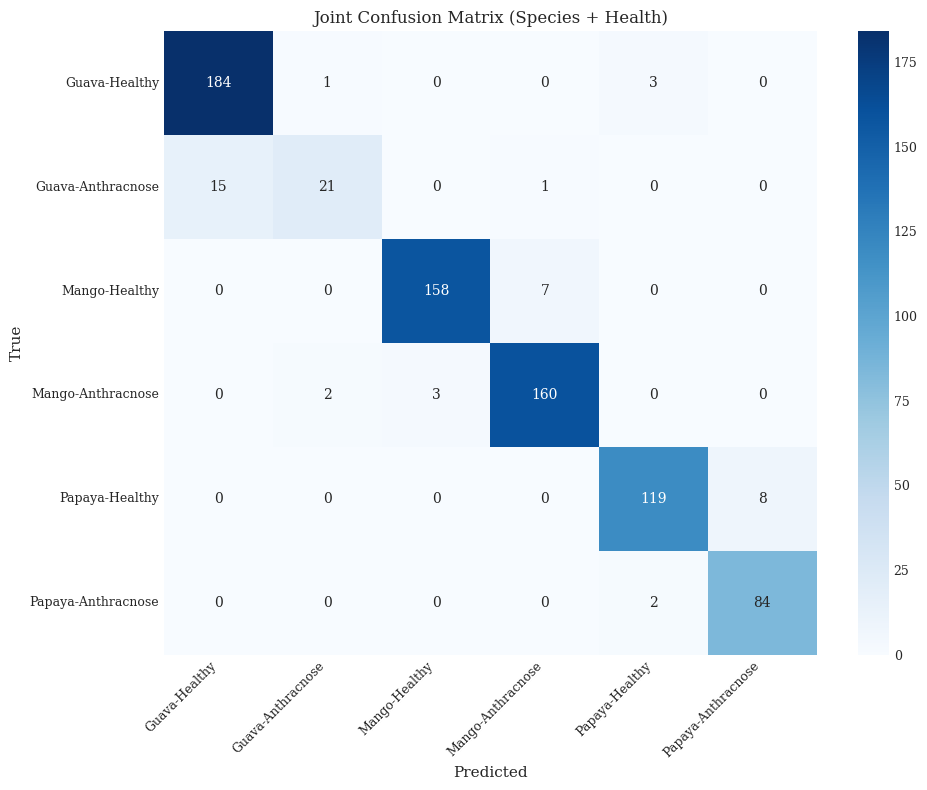

✓ Confusion matrix saved to joint_confusion_matrix.png
--------------------------------------------------------------------------------

✓ Saved final model as 'final_multitask_ResNet_50.pt'

Running Final Test



/tmp/ipykernel_2204/1179938579.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  [2/24] loss: 1.1544, sp: 0.984, he: 0.766, both: 0.750
  [4/24] loss: 0.6093, sp: 0.984, he: 0.875, both: 0.859
  [6/24] loss: 0.4212, sp: 0.984, he: 0.917, both: 0.901
  [8/24] loss: 0.3325, sp: 0.984, he: 0.938, both: 0.922
  [10/24] loss: 0.2966, sp: 0.984, he: 0.944, both: 0.928
  [12/24] loss: 0.2600, sp: 0.984, he: 0.951, both: 0.935
  [14/24] loss: 0.2323, sp: 0.987, he: 0.955, both: 0.942
  [16/24] loss: 0.2249, sp: 0.988, he: 0.953, both: 0.941
  [18/24] loss: 0.2082, sp: 0.990, he: 0.953, both: 0.943
  [20/24] loss: 0.1941, sp: 0.991, he: 0.956, both: 0.947
  [22/24] loss: 0.1878, sp: 0.991, he: 0.957, both: 0.949
  [24/24] loss: 0.1953, sp: 0.992, he: 0.953, both: 0.945

Final Test Results:
  loss: 0.1953 | species: 0.992 | health: 0.953 | both: 0.945 | f1_joint: 0.910

Training completed for best_multitask_ResNet_50.pt
Best validation both accuracy: 0.933
  - convergence_best_multitask_resnet_50.pt.png
  - lr_schedule_best_multitask_resnet_50.pt.png
  - history_best_multi

In [6]:
# -------------------------------
# Test the best model
# -------------------------------

MODEL_NAME = "best_multitask_ResNet_50.pt"

print("Testing best model on test set...")
checkpoint = torch.load("best_multitask_ResNet_50.pt", map_location=device)
model.load_state_dict(checkpoint["model"])
print(f"Loaded best model from epoch {checkpoint['epoch']+1} with val_both={checkpoint['val_both']:.3f}")

# Running the test phase
test_stats = run_epoch(test_loader, model, optimizer=None, train=False)
print(f"\n{'TEST SET RESULTS':^80}")
print("-"*80)
print(f"  Loss: {test_stats['loss']:.4f}")
print(f"  Species Accuracy: {test_stats['acc_species']:.4f} ({test_stats['acc_species']*100:.2f}%)")
print(f"  Health Accuracy:  {test_stats['acc_health']:.4f} ({test_stats['acc_health']*100:.2f}%)")
print(f"  Both Correct:     {test_stats['acc_both']:.4f} ({test_stats['acc_both']*100:.2f}%)")
print(f"  Joint Macro F1:   {test_stats['f1_joint']:.4f}")

# Plot Joint Confusion Matrix
if 'y_true' in test_stats and 'y_pred' in test_stats:
    plot_joint_confusion_matrix(test_stats['y_true'], test_stats['y_pred'])
print("-"*80 + "\n")

# Save final model
torch.save({"model": model.state_dict(),
            "epoch": EPOCHS - 1,
            "test_stats": test_stats,
            "spec": {"species_map": SPECIES_MAP, "health_map": HEALTH_MAP}},
           "final_multitask_ResNet_50.pt")
print("✓ Saved final model as 'final_multitask_ResNet_50.pt'\n")


# -------------------------------
# Final test phase (Additional)
# -------------------------------
print("="*80)
print("Running Final Test")
print("="*80 + "\n")

with torch.no_grad():
    final_test_stats = run_epoch(test_loader, model, optimizer=None, train=False, epoch=EPOCHS-1)

# Display Final Test Results
print("\n" + "="*80)
print("Final Test Results:")
print(f"  loss: {final_test_stats['loss']:.4f} | species: {final_test_stats['acc_species']:.3f} | health: {final_test_stats['acc_health']:.3f} | both: {final_test_stats['acc_both']:.3f} | f1_joint: {final_test_stats['f1_joint']:.3f}")
print("="*80)

# -------------------------------
# Summary & Visualizations
# -------------------------------
print(f"\nTraining completed for {MODEL_NAME}")
print(f"Best validation both accuracy: {best_val_both:.3f}")

# Visualizations saved:
print(f"  - convergence_{MODEL_NAME.lower().replace('-', '_')}.png")
print(f"  - lr_schedule_{MODEL_NAME.lower().replace('-', '_')}.png")
print(f"  - history_{MODEL_NAME.lower().replace('-', '_')}.csv")
print("="*80)


## plot saving

In [7]:
# -------------------------------
# Save Individual Training Plots
# -------------------------------
print("\nGenerating individual training plots...")

epochs_range = range(1, len(history['train_loss']) + 1)

# 1. Training Loss
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_train_loss.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_train_loss.png")
plt.close()

# 2. Validation Loss
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['val_loss'], 'r-o', label='Validation Loss', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Validation Loss Over Epochs', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_val_loss.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_val_loss.png")
plt.close()

# 3. Train vs Val Loss Comparison
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
ax.plot(epochs_range, history['val_loss'], 'r-o', label='Val Loss', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_loss_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_loss_comparison.png")
plt.close()

# 4. Species Accuracy
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['train_acc_species'], 'b-o', label='Train Species Acc', linewidth=2, markersize=6)
ax.plot(epochs_range, history['val_acc_species'], 'r-o', label='Val Species Acc', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Species Classification Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('plot_species_accuracy.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_species_accuracy.png")
plt.close()

# 5. Health Accuracy
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['train_acc_health'], 'b-o', label='Train Health Acc', linewidth=2, markersize=6)
ax.plot(epochs_range, history['val_acc_health'], 'r-o', label='Val Health Acc', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Health/Disease Classification Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('plot_health_accuracy.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_health_accuracy.png")
plt.close()

# 6. Joint (Both) Accuracy
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['train_acc_both'], 'b-o', label='Train Both Acc', linewidth=2, markersize=6)
ax.plot(epochs_range, history['val_acc_both'], 'r-o', label='Val Both Acc', linewidth=2, markersize=6)
ax.axhline(y=best_val_both, color='g', linestyle='--', linewidth=2, label=f'Best Val Both: {best_val_both:.3f}')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Joint Classification Accuracy (Both Tasks Correct)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('plot_joint_accuracy.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_joint_accuracy.png")
plt.close()

# 7. All Accuracies Together (Optional comprehensive view)
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(epochs_range, history['train_acc_species'], 'b-o', label='Train Species', linewidth=2, markersize=5)
ax.plot(epochs_range, history['val_acc_species'], 'b--s', label='Val Species', linewidth=2, markersize=5)
ax.plot(epochs_range, history['train_acc_health'], 'g-o', label='Train Health', linewidth=2, markersize=5)
ax.plot(epochs_range, history['val_acc_health'], 'g--s', label='Val Health', linewidth=2, markersize=5)
ax.plot(epochs_range, history['train_acc_both'], 'r-o', label='Train Both', linewidth=2, markersize=5)
ax.plot(epochs_range, history['val_acc_both'], 'r--s', label='Val Both', linewidth=2, markersize=5)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('All Metrics Over Training', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('plot_all_metrics.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_all_metrics.png")
plt.close()

print("\n" + "="*80)
print("All training plots saved:")
print("  - plot_train_loss.png")
print("  - plot_val_loss.png")
print("  - plot_loss_comparison.png")
print("  - plot_species_accuracy.png")
print("  - plot_health_accuracy.png")
print("  - plot_joint_accuracy.png")
print("  - plot_all_metrics.png")
print("="*80 + "\n")


Generating individual training plots...
✓ Saved plot_train_loss.png
✓ Saved plot_val_loss.png
✓ Saved plot_loss_comparison.png
✓ Saved plot_species_accuracy.png
✓ Saved plot_health_accuracy.png
✓ Saved plot_joint_accuracy.png
✓ Saved plot_all_metrics.png

All training plots saved:
  - plot_train_loss.png
  - plot_val_loss.png
  - plot_loss_comparison.png
  - plot_species_accuracy.png
  - plot_health_accuracy.png
  - plot_joint_accuracy.png
  - plot_all_metrics.png



## metrics

Loaded best model from epoch 12 with val_both=0.933
Running comprehensive test evaluation...

COMPREHENSIVE TEST RESULTS

                               OVERALL ACCURACIES                               
--------------------------------------------------------------------------------
  Species Classification:  0.9922 (99.22%)
  Health Classification:   0.9531 (95.31%)
  Both Correct (Joint):    0.9453 (94.53%)

                         SPECIES CLASSIFICATION REPORT                          
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

       Guava     0.9910    0.9822    0.9866       225
       Mango     0.9970    0.9939    0.9954       330
      Papaya     0.9861    1.0000    0.9930       213

    accuracy                         0.9922       768
   macro avg     0.9914    0.9921    0.9917       768
weighted avg     0.9922    0.9922    0.9922       768


                      HEALTH/DISEASE CLASS

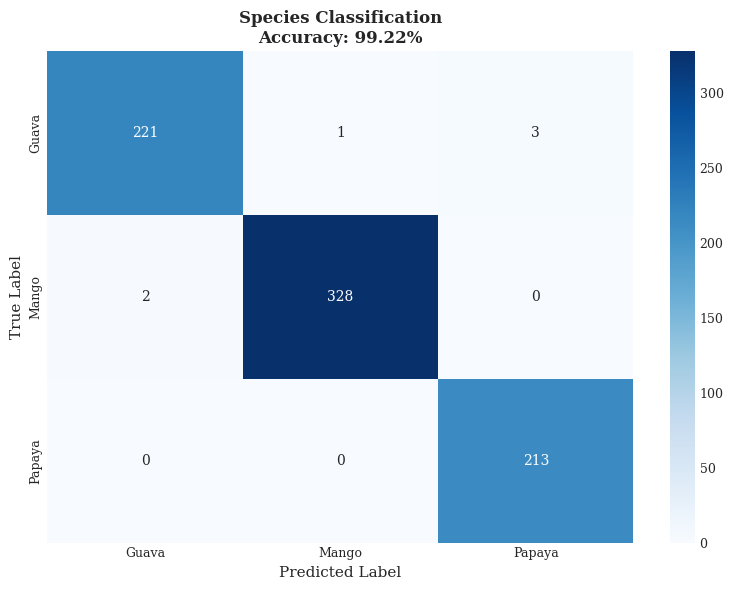

Saved health confusion matrix to 'confusion_matrix_health.png'


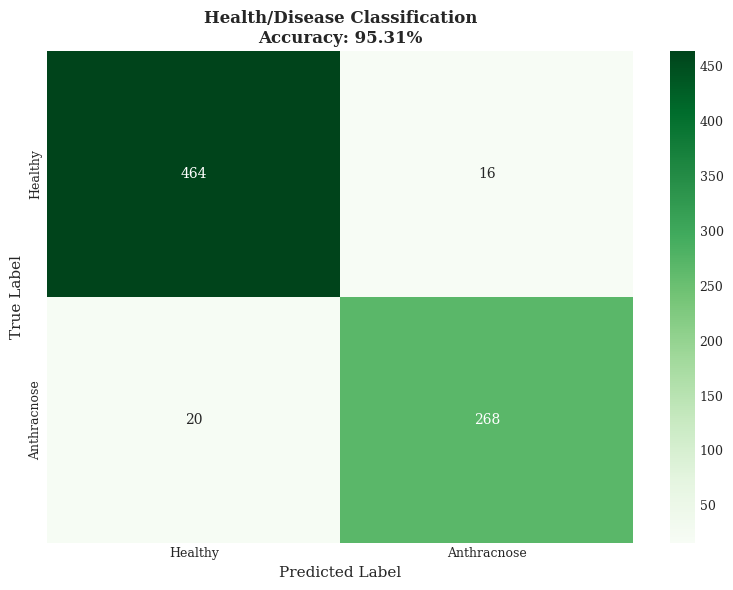

Saved joint accuracy heatmap to 'joint_accuracy_heatmap.png'


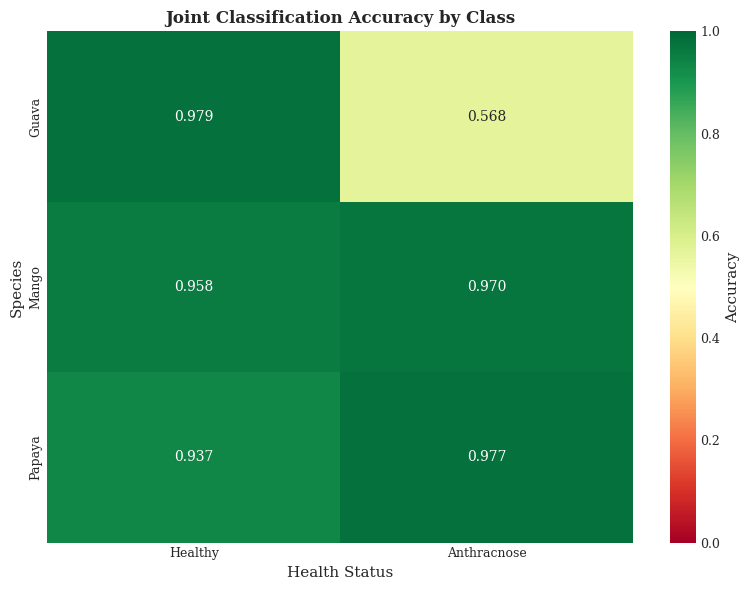


Testing complete! Generated visualizations:
  - confusion_matrices.png
  - sample_predictions.png
  - joint_accuracy_heatmap.png



In [8]:

# -------------------------------
# Comprehensive Testing Function
# -------------------------------
def comprehensive_test(model, test_loader, device, species_map, health_map):
    """
    Perform comprehensive testing with metrics and visualizations
    """
    model.eval()
    
    # Storage for predictions and ground truth
    all_species_preds = []
    all_species_true = []
    all_health_preds = []
    all_health_true = []
    all_both_correct = []
    
    # For visualization: store some sample predictions
    sample_images = []
    sample_predictions = []
    sample_ground_truth = []
    max_samples = 20  # Number of samples to visualize
    
    print("Running comprehensive test evaluation...")
    
    with torch.no_grad():
        for batch_idx, (imgs, y_species, y_health) in enumerate(test_loader):
            imgs = imgs.to(device, non_blocking=True)
            y_species = y_species.to(device, non_blocking=True)
            y_health = y_health.to(device, non_blocking=True)
            
            # Get predictions
            logits_species, logits_health = model(imgs)
            preds_species = logits_species.argmax(dim=1)
            preds_health = logits_health.argmax(dim=1)
            
            # Store predictions and ground truth
            all_species_preds.extend(preds_species.cpu().numpy())
            all_species_true.extend(y_species.cpu().numpy())
            all_health_preds.extend(preds_health.cpu().numpy())
            all_health_true.extend(y_health.cpu().numpy())
            
            # Check if both predictions are correct
            both_correct = ((preds_species == y_species) & (preds_health == y_health)).cpu().numpy()
            all_both_correct.extend(both_correct)
            
            # Store samples for visualization
            if len(sample_images) < max_samples:
                for i in range(min(imgs.size(0), max_samples - len(sample_images))):
                    sample_images.append(imgs[i].cpu())
                    sample_predictions.append({
                        'species': preds_species[i].item(),
                        'health': preds_health[i].item()
                    })
                    sample_ground_truth.append({
                        'species': y_species[i].item(),
                        'health': y_health[i].item()
                    })
    
    # Convert to numpy arrays
    all_species_preds = np.array(all_species_preds)
    all_species_true = np.array(all_species_true)
    all_health_preds = np.array(all_health_preds)
    all_health_true = np.array(all_health_true)
    all_both_correct = np.array(all_both_correct)
    
    # Reverse mapping for labels
    species_labels = {v: k.capitalize() for k, v in species_map.items()}
    health_labels = {v: k.capitalize() for k, v in health_map.items()}
    
    # -------------------------------
    # Print Metrics
    # -------------------------------
    print("\n" + "="*80)
    print("COMPREHENSIVE TEST RESULTS")
    print("="*80)
    
    # Overall accuracies
    species_acc = accuracy_score(all_species_true, all_species_preds)
    health_acc = accuracy_score(all_health_true, all_health_preds)
    both_acc = all_both_correct.mean()
    
    print(f"\n{'OVERALL ACCURACIES':^80}")
    print("-"*80)
    print(f"  Species Classification:  {species_acc:.4f} ({species_acc*100:.2f}%)")
    print(f"  Health Classification:   {health_acc:.4f} ({health_acc*100:.2f}%)")
    print(f"  Both Correct (Joint):    {both_acc:.4f} ({both_acc*100:.2f}%)")
    
    # Species Classification Report
    print(f"\n{'SPECIES CLASSIFICATION REPORT':^80}")
    print("-"*80)
    print(classification_report(
        all_species_true, 
        all_species_preds,
        target_names=[species_labels[i] for i in sorted(species_labels.keys())],
        digits=4
    ))
    
    # Health Classification Report
    print(f"\n{'HEALTH/DISEASE CLASSIFICATION REPORT':^80}")
    print("-"*80)
    print(classification_report(
        all_health_true, 
        all_health_preds,
        target_names=[health_labels[i] for i in sorted(health_labels.keys())],
        digits=4
    ))
    
    # Per-class joint accuracy
    print(f"\n{'PER-CLASS JOINT ACCURACY':^80}")
    print("-"*80)
    for sp_id in sorted(species_labels.keys()):
        for he_id in sorted(health_labels.keys()):
            # Find samples of this joint class
            mask = (all_species_true == sp_id) & (all_health_true == he_id)
            if mask.sum() > 0:
                joint_acc = all_both_correct[mask].mean()
                count = mask.sum()
                sp_name = species_labels[sp_id]
                he_name = health_labels[he_id]
                print(f"  {sp_name:8s} + {he_name:12s}: {joint_acc:.4f} ({joint_acc*100:.2f}%) [{count:4d} samples]")
    
    # -------------------------------
    # Visualizations
    # -------------------------------
    
    # 1. Confusion Matrices - Individual Images

    # Species confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    cm_species = confusion_matrix(all_species_true, all_species_preds)
    sns.heatmap(cm_species, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=[species_labels[i] for i in sorted(species_labels.keys())],
                yticklabels=[species_labels[i] for i in sorted(species_labels.keys())])
    ax.set_title(f'Species Classification\nAccuracy: {species_acc:.2%}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig('confusion_matrix_species.png', dpi=150, bbox_inches='tight')
    print(f"Saved species confusion matrix to 'confusion_matrix_species.png'")
    plt.show()
    plt.close()


    # Health confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    cm_health = confusion_matrix(all_health_true, all_health_preds)
    sns.heatmap(cm_health, annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=[health_labels[i] for i in sorted(health_labels.keys())],
                yticklabels=[health_labels[i] for i in sorted(health_labels.keys())])
    ax.set_title(f'Health/Disease Classification\nAccuracy: {health_acc:.2%}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig('confusion_matrix_health.png', dpi=150, bbox_inches='tight')
    print(f"Saved health confusion matrix to 'confusion_matrix_health.png'")
    plt.show()
    plt.close()
   
    
    
    
    # 3. Joint Accuracy Heatmap
    fig, ax = plt.subplots(figsize=(8, 6))
    joint_acc_matrix = np.zeros((len(species_labels), len(health_labels)))
    
    for sp_id in sorted(species_labels.keys()):
        for he_id in sorted(health_labels.keys()):
            mask = (all_species_true == sp_id) & (all_health_true == he_id)
            if mask.sum() > 0:
                joint_acc_matrix[sp_id, he_id] = all_both_correct[mask].mean()
    
    sns.heatmap(joint_acc_matrix, annot=True, fmt='.3f', cmap='RdYlGn', 
                xticklabels=[health_labels[i] for i in sorted(health_labels.keys())],
                yticklabels=[species_labels[i] for i in sorted(species_labels.keys())],
                vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'Accuracy'})
    ax.set_title('Joint Classification Accuracy by Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Species')
    ax.set_xlabel('Health Status')
    
    plt.tight_layout()
    plt.savefig('joint_accuracy_heatmap.png', dpi=150, bbox_inches='tight')
    print(f"Saved joint accuracy heatmap to 'joint_accuracy_heatmap.png'")
    plt.show()
    plt.close()
    
    print("\n" + "="*80)
    print("Testing complete! Generated visualizations:")
    print("  - confusion_matrices.png")
    print("  - sample_predictions.png")
    print("  - joint_accuracy_heatmap.png")
    print("="*80 + "\n")
    
    return {
        'species_accuracy': species_acc,
        'health_accuracy': health_acc,
        'joint_accuracy': both_acc,
        'species_preds': all_species_preds,
        'species_true': all_species_true,
        'health_preds': all_health_preds,
        'health_true': all_health_true
    }


# -------------------------------
# Usage: Run after training
# -------------------------------

# Load the best model
checkpoint = torch.load("best_multitask_ResNet_50.pt", map_location=device)
model.load_state_dict(checkpoint["model"])
print(f"Loaded best model from epoch {checkpoint['epoch']+1} with val_both={checkpoint['val_both']:.3f}")

# Run comprehensive testing
test_results = comprehensive_test(
    model=model,
    test_loader=test_loader,
    device=device,
    species_map=SPECIES_MAP,
    health_map=HEALTH_MAP
)

## 10 sample visualisation from 3 class

Saved sample predictions (30 total: 10 per class) to 'sample_predictions.png'


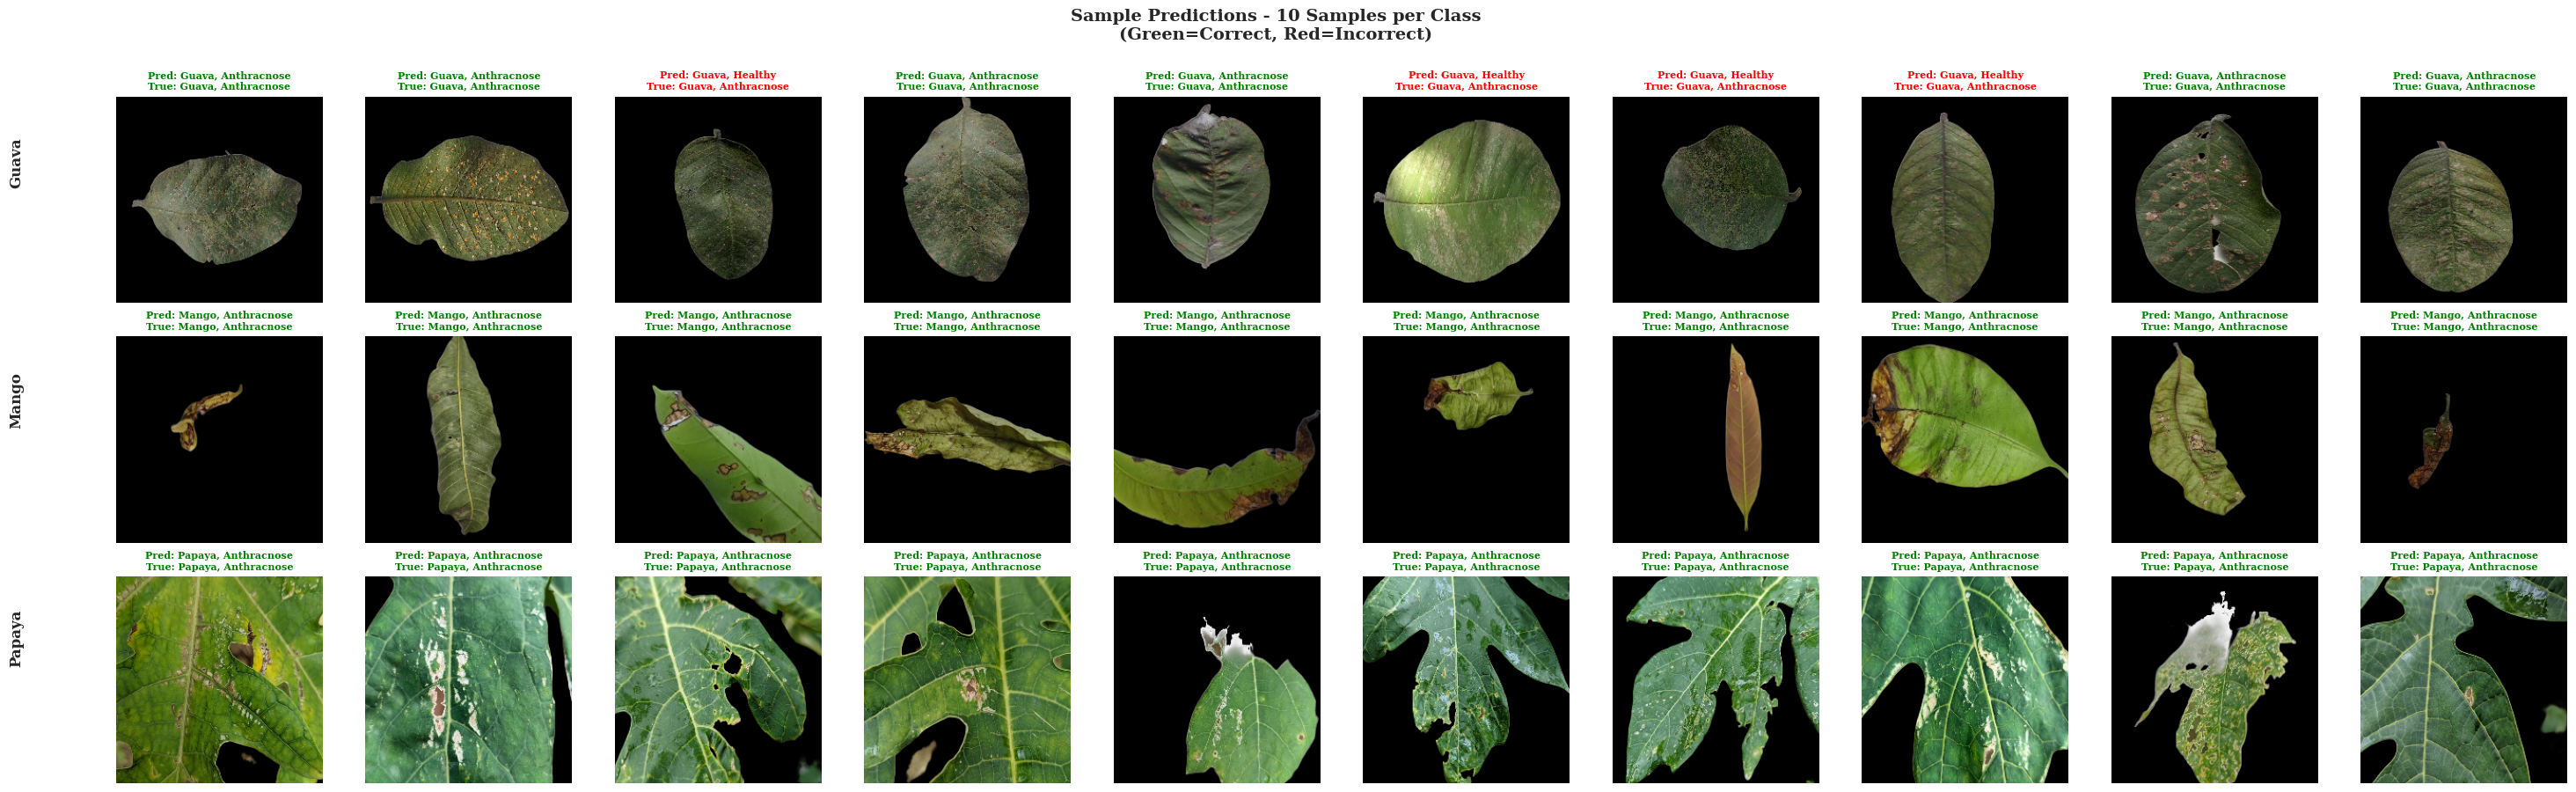

In [9]:
# Load model
species_labels = {
    0: 'Guava',
    1: 'Mango',
    2: 'Papaya'
}

health_labels = {
    0: 'Healthy',
    1: 'Anthracnose',
}

checkpoint = torch.load("best_multitask_ResNet_50.pt")
model.load_state_dict(checkpoint["model"])
model.eval()

# Number of samples to display per class
amount = 10

# Collect samples from validation set
sample_images_by_class = {0: [], 1: [], 2: []}
sample_predictions_by_class = {0: [], 1: [], 2: []}
sample_ground_truth_by_class = {0: [], 1: [], 2: []}

with torch.no_grad():
    for images, species_batch, health_batch in val_loader:
        images = images.to(device)
        
        outputs = model(images)
        species_preds = outputs[0].argmax(1)
        health_preds = outputs[1].argmax(1)
        
        for i in range(len(images)):
            species_class = species_batch[i].item()
            
            if len(sample_images_by_class[species_class]) < amount:
                sample_images_by_class[species_class].append(images[i].cpu())
                sample_predictions_by_class[species_class].append({
                    'species': species_preds[i].item(),
                    'health': health_preds[i].item()
                })
                sample_ground_truth_by_class[species_class].append({
                    'species': species_batch[i].item(),
                    'health': health_batch[i].item()
                })
        
        if all(len(samples) >= amount for samples in sample_images_by_class.values()):
            break

# Visualize
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(3, amount, figsize=(3*amount, 9))

for row, species_idx in enumerate(sorted(sample_images_by_class.keys())):
    for col in range(amount):
        ax = axes[row, col]
        
        img = sample_images_by_class[species_idx][col]
        pred = sample_predictions_by_class[species_idx][col]
        gt = sample_ground_truth_by_class[species_idx][col]
        
        # Denormalize and display
        img_display = img.numpy().transpose(1, 2, 0)
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1)
        
        ax.imshow(img_display)
        ax.axis('off')
        
        # Check correctness
        both_correct = (pred['species'] == gt['species']) and (pred['health'] == gt['health'])
        
        # Create title
        pred_sp = species_labels[pred['species']]
        pred_he = health_labels[pred['health']]
        gt_sp = species_labels[gt['species']]
        gt_he = health_labels[gt['health']]
        
        title = f"Pred: {pred_sp}, {pred_he}\nTrue: {gt_sp}, {gt_he}"
        color = 'green' if both_correct else 'red'
        ax.set_title(title, fontsize=8, color=color, fontweight='bold')
    
    # Add species label
    fig.text(0.02, 0.5 + (1 - row) * 0.3, species_labels[species_idx], 
             fontsize=12, fontweight='bold', va='center', rotation=90)

plt.suptitle(f'Sample Predictions - {amount} Samples per Class\n(Green=Correct, Red=Incorrect)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0.05, 0, 1, 0.99])
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
print(f"Saved sample predictions ({3*amount} total: {amount} per class) to 'sample_predictions.png'")
plt.show()
plt.close()